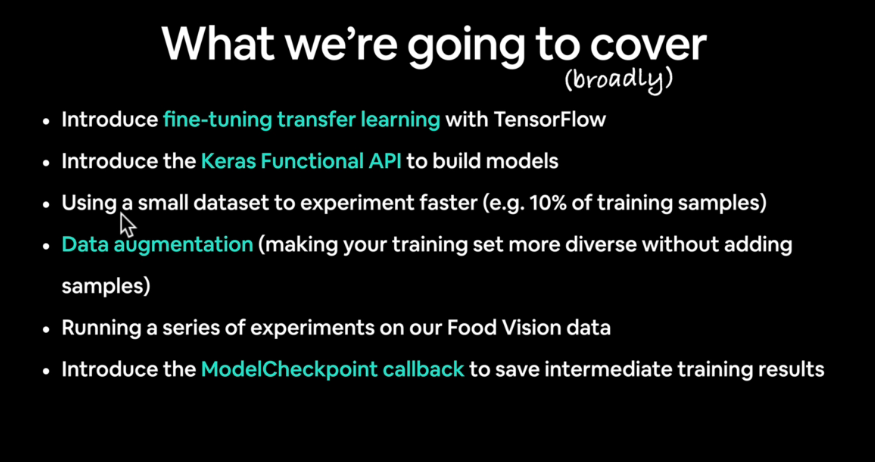

<h1 style="color:red">lec 002:-Importing a script full of helper functions (and saving lots of space).mp4</h1>

# Transfer Learning with TensorFlow Part 2: Fine-tuning

In the previous notebook, we covered transfer learning feature extraction, now it's time to learn about a new kind of transfer learning: fine-tuning.

In [1]:
# Check if we're using a GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## Creating helper functions

In previous notebooks, we've created a bunch of helper functions, now we could rewrite them all, however, this is tedious.

So, it's a good idea to put functions you'll want to use again in a script you can download and import into your notebooks (or elsewhere).

We've done this for the functions we've used previously here: https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

In [2]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-02-07 16:34:52--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-02-07 16:34:52 (25.8 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [3]:
# Import helper functions we're going to use in this notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves,unzip_data,walk_through_dir

> 🔑**Note:** If you're running this notebook in Google Colab, when it times out Colab will delete `helper_functions.py`, so you'll have to redownload it if you want access to your helper functions.

<h1 style="color:red">lec 003:-Downloading and turning our images into a TensorFlow BatchDataset.mp4</h1>

## Let's get some data

This time we're going to see how we can use the pretrained models within tf.keras.applications and apply them to our own problem (recognizing images of food).

link: https://www.tensorflow.org/api_docs/python/tf/keras/applications

In [4]:
# Get 10% of training data of 10 classes of Food101
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

unzip_data("10_food_classes_10_percent.zip")



# # Create function to unzip a zipfile into current working directory
# # (since we're going to be downloading and unzipping a few files)
# import zipfile

# def unzip_data(filename):
#   """
#   Unzips filename into the current working directory.

#   Args:
#     filename (str): a filepath to a target zip folder to be unzipped.
#   """
#   zip_ref = zipfile.ZipFile(filename, "r")
#   zip_ref.extractall()
#   zip_ref.close()

--2026-02-07 16:35:21--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.216.207, 142.250.98.207, 142.251.107.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.216.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M  98.4MB/s    in 1.6s    

2026-02-07 16:35:22 (98.4 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [5]:
# Check out how many images and subdirectories are in our datset
walk_through_dir("10_food_classes_10_percent")


## Walk through an image classification directory and find out how many files (images)
## are in each subdirectory.
# import os

# def walk_through_dir(dir_path):
#   """
#   Walks through dir_path returning its contents.

#   Args:
#     dir_path (str): target directory

#   Returns:
#     A print out of:
#       number of subdiretories in dir_path
#       number of images (files) in each subdirectory
#       name of each subdirectory
#   """
#   for dirpath, dirnames, filenames in os.walk(dir_path):
#     print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/c

In [6]:
# Create training and test directory paths
train_dir ="/content/10_food_classes_10_percent/train"
test_dir = "/content/10_food_classes_10_percent/test"

In [1]:
import tensorflow as tf
IMG_SIZE = (224,224)

# we're going to use image_dataset_from directory instead of images.ImageDataGenerator because that is fast
train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode="categorical",
                                                                            batch_size=32)
test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                          image_size=IMG_SIZE,
                                                                          label_mode="categorical",
                                                                          batch_size=32)

NameError: name 'train_dir' is not defined

In [8]:
train_data_10_percent

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>

In [9]:
# Check out the class names of our dataset
train_data_10_percent.class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']

In [10]:
# See an example of batch of data
for images,labels in train_data_10_percent.take(1): # take do unravel the batch
  print(images,labels)


tf.Tensor(
[[[[2.10000000e+01 2.10000000e+01 1.90000000e+01]
   [2.18549099e+01 2.18549099e+01 1.98549099e+01]
   [2.20000000e+01 2.20000000e+01 2.00000000e+01]
   ...
   [2.58168240e+01 3.38168221e+01 3.68168221e+01]
   [2.70610771e+01 3.40610771e+01 4.00610771e+01]
   [2.78549099e+01 3.48549118e+01 4.08549118e+01]]

  [[2.08445473e+01 2.08445473e+01 1.88445473e+01]
   [2.10000000e+01 2.10000000e+01 1.90000000e+01]
   [2.15647316e+01 2.15647316e+01 1.95647316e+01]
   ...
   [2.64352684e+01 3.44352684e+01 3.74352684e+01]
   [2.61605606e+01 3.35958290e+01 3.82900238e+01]
   [2.67201996e+01 3.37201996e+01 3.97201996e+01]]

  [[2.01764984e+01 2.01764984e+01 1.81764984e+01]
   [2.09481831e+01 2.09481831e+01 1.89481831e+01]
   [2.10000000e+01 2.10000000e+01 1.90000000e+01]
   ...
   [2.64299908e+01 3.44299889e+01 3.74299889e+01]
   [2.50714417e+01 3.30714417e+01 3.60714417e+01]
   [2.70826244e+01 3.40826225e+01 4.00826225e+01]]

  ...

  [[1.74509277e+01 1.64509277e+01 1.24509277e+01]
   [1

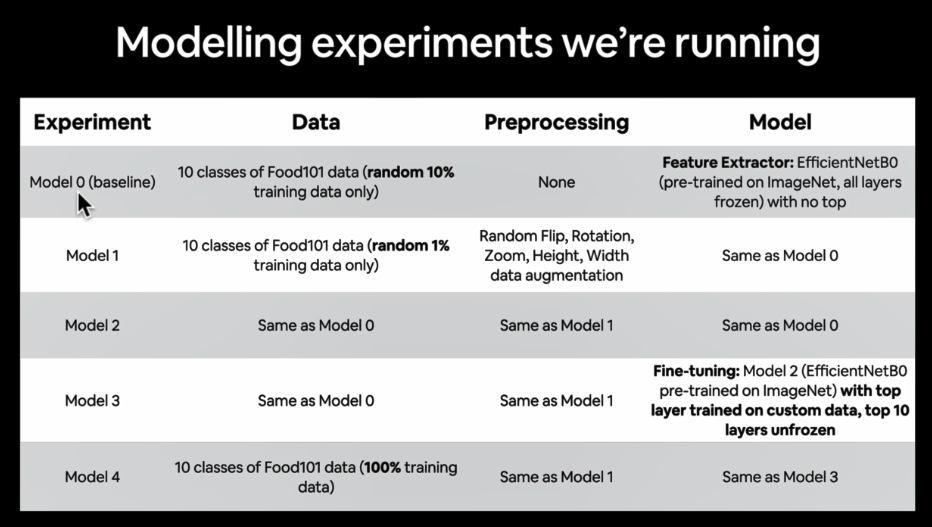

<h1 style="color:red">lec 005:-Comparing the TensorFlow Keras Sequential API versus the Functional API.mp4</h1>

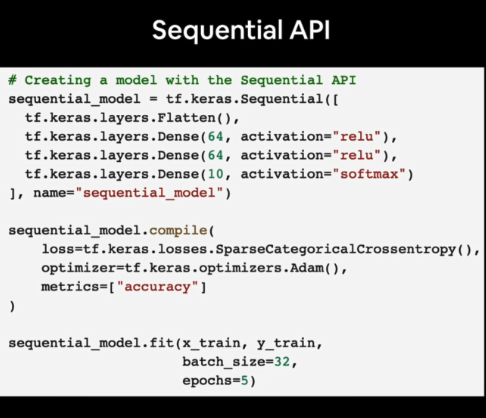

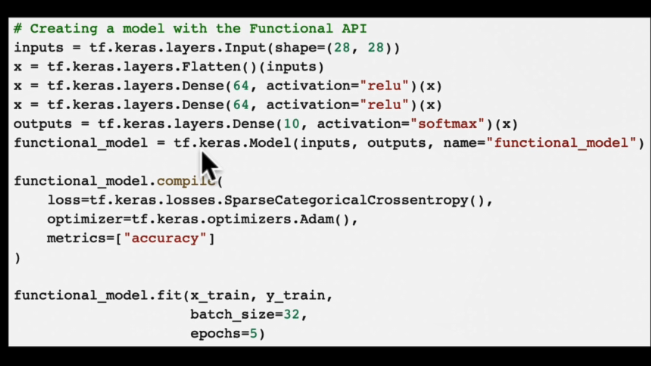

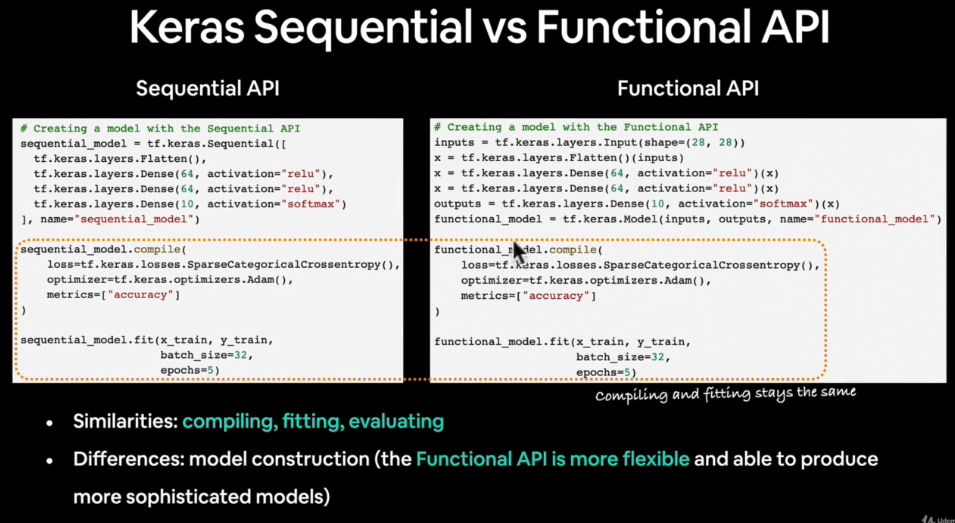

<h1 style="color:red">lec 006:-Creating our first model with the TensorFlow Keras Functional API.mp4</h1>

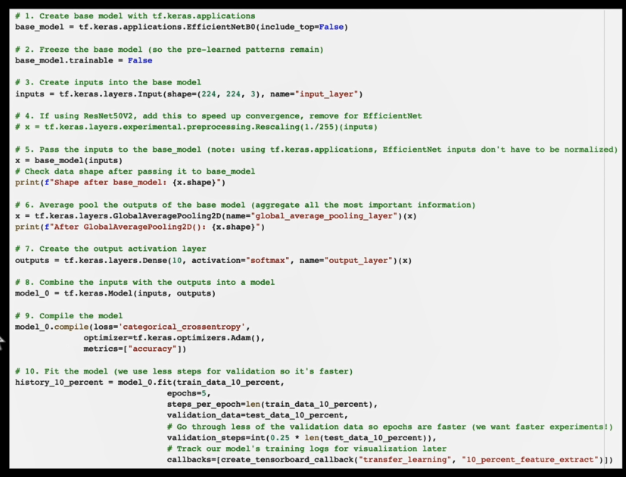

## Model 0: Building a transfer learning model using the Keras Functional API

The sequential API is straight-forward, it runs our layers in sequential order.

But the functional API gives us more flexibility with our models - https://keras.io/guides/functional_api/

https://www.tensorflow.org/guide/keras/functional_api

In [11]:
# 1. Create base model using tf.keras.applications
base_model = tf.keras.applications.EfficientNetB0(include_top=False)

# 2. Freeze the base model (so the underlying pre-trained patterns aren't updated during training)
base_model.trainable = False

# 3. Create inputs into our model
inputs = tf.keras.layers.Input(shape=(224,224,3),name="input_layer")

# 4. If using Resnet50V2 you will need to normalize inputs (you don't have to for EfficientNet(s))
# x = tf.keras.layers.experimental.preprocessing.Rescaling(1/255.0)(inputs)

# 5. Pass the inputs to the base_model
x = base_model(inputs)
print(f"Shape after passing inputs through base model: {x.shape}")

# 6. Average pool the outputs of the base model (aggregate all the most important information, reduce number of computations)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
print(f"Shape after GlobalAveragePooling2D: {x.shape}")

# 7. Create the output activation layer
outputs = tf.keras.layers.Dense(10,activation="softmax",name="output_layer")(x)

# 8. Combine the inputs with the outputs into a model
model_0 = tf.keras.Model(inputs,outputs)

# 9. Compile the model
model_0.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 10. Fit the model and save its history
history_10_percent = model_0.fit(train_data_10_percent,
                                 epochs=5,
                                 steps_per_epoch = len(train_data_10_percent),
                                 validation_data=test_data,
                                 validation_steps=int(0.25*len(test_data)),
                                 callbacks=[create_tensorboard_callback(dir_name="transfer_learning",
                                                                        experiment_name="10_percent_feature_extraction")])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape after passing inputs through base model: (None, 7, 7, 1280)
Shape after GlobalAveragePooling2D: (None, 1280)
Saving TensorBoard log files to: transfer_learning/10_percent_feature_extraction/20260207-163527
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 117s 4s/step - accuracy: 0.2535 - loss: 2.1012 - val_accuracy: 0.7122 - val_loss: 1.3172
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step - accuracy: 0.7259 - loss: 1.1951 - val_accuracy: 0.8141 - val_loss: 0.8956
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 150s 5s/step - accuracy: 0.7966 - loss: 0.8363 - val_accuracy: 0.8553 - val_loss: 0.6979
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 102s 4s/step - accuracy: 0.8565 - loss: 0.6638 - val_accuracy: 0.8569 - val_loss: 0.6241
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 205s 7s/step - accuracy: 0.8668 - loss: 0.5490 - val_accuracy: 0.8766 - val_loss: 0.5592


In [12]:
# Evaluate on full test dataset
model_0.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.8669 - loss: 0.5660


[0.5571695566177368, 0.8623999953269958]

In [13]:
# Check the layers in our base model
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number,layer) # we can also use layer.name instead of layer

0 <InputLayer name=input_layer, built=True>
1 <Rescaling name=rescaling, built=True>
2 <Normalization name=normalization, built=True>
3 <Rescaling name=rescaling_1, built=True>
4 <ZeroPadding2D name=stem_conv_pad, built=True>
5 <Conv2D name=stem_conv, built=True>
6 <BatchNormalization name=stem_bn, built=True>
7 <Activation name=stem_activation, built=True>
8 <DepthwiseConv2D name=block1a_dwconv, built=True>
9 <BatchNormalization name=block1a_bn, built=True>
10 <Activation name=block1a_activation, built=True>
11 <GlobalAveragePooling2D name=block1a_se_squeeze, built=True>
12 <Reshape name=block1a_se_reshape, built=True>
13 <Conv2D name=block1a_se_reduce, built=True>
14 <Conv2D name=block1a_se_expand, built=True>
15 <Multiply name=block1a_se_excite, built=True>
16 <Conv2D name=block1a_project_conv, built=True>
17 <BatchNormalization name=block1a_project_bn, built=True>
18 <Conv2D name=block2a_expand_conv, built=True>
19 <BatchNormalization name=block2a_expand_bn, built=True>
20 <Activat

In [14]:
# How about we get a summary of the base model?
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
# How about a summary of our whole model?
model_0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

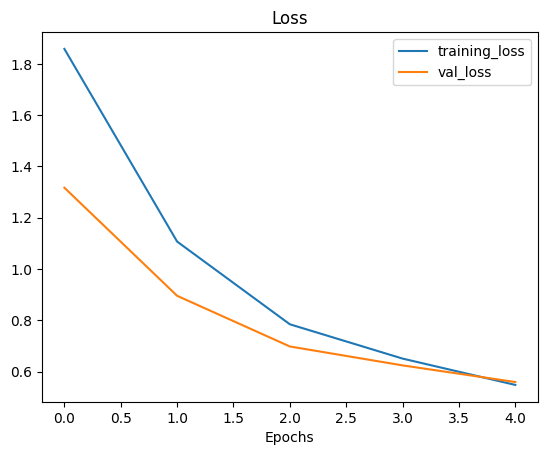

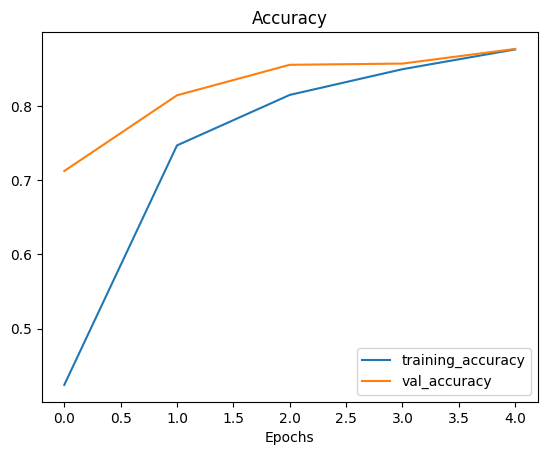

In [16]:
# Check out our model's training curves
plot_loss_curves(history_10_percent)

<h1 style="color:red">lec 008:-Getting a feature vector from our trained model.mp4</h1>

## Getting a feature vector from a trained model

Let's demonstrate the Global Average Pooling 2D layer...

We have a tensor after our model goes through `base_model` of shape (None, 7, 7, 1280)...

But then when it passes through GlobalAveragePooling2D, it turns into (None, 1280).

Let's use a similar shaped tensor of (1,4,4,3) and then pass it to GlobalAveragePooling2D.

In [17]:
# Define the input shape
input_shape = (1,4,4,3)

# Create a random tensor
tf.random.set_seed(42)
input_tensor = tf.random.normal(input_shape)
print(f"Input tensor:\n {input_tensor}\n")

# Pass the random tensor through a global average pooling 2D layer
global_average_pooled_tensor = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)
print(f"Global average pooled random tensor:\n {global_average_pooled_tensor}\n")

# Check the shape of different tensors
print(f"Shape of input tensor: {input_tensor.shape}")
print(f"Shape of global average pooled tensor: {global_average_pooled_tensor.shape}")

Input tensor:
 [[[[ 0.3274685  -0.8426258   0.3194337 ]
   [-1.4075519  -2.3880599  -1.0392479 ]
   [-0.5573232   0.539707    1.6994323 ]
   [ 0.28893656 -1.5066116  -0.26454744]]

  [[-0.59722406 -1.9171132  -0.62044144]
   [ 0.8504023  -0.40604794 -3.0258412 ]
   [ 0.9058464   0.29855987 -0.22561555]
   [-0.7616443  -1.891714   -0.9384712 ]]

  [[ 0.77852213 -0.47338897  0.97772694]
   [ 0.24694404  0.20573747 -0.5256233 ]
   [ 0.32410017  0.02545409 -0.10638497]
   [-0.6369475   1.1603122   0.2507359 ]]

  [[-0.41728497  0.40125778 -1.4145442 ]
   [-0.59318566 -1.6617213   0.33567193]
   [ 0.10815629  0.2347968  -0.56668764]
   [-0.35819843  0.88698626  0.5274477 ]]]]

Global average pooled random tensor:
 [[-0.09368646 -0.45840445 -0.28855976]]

Shape of input tensor: (1, 4, 4, 3)
Shape of global average pooled tensor: (1, 3)


In [18]:
# Let's replicate the GlobalAveragePool2D layer
tf.reduce_mean(input_tensor, axis=[1,2]) # reduce mean accross axis position 1,2 in shape

<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[-0.09368646, -0.45840445, -0.28855976]], dtype=float32)>

<h1 style="color:red">lec 009:-Drilling into the concept of a feature vector (a learned representation).mp4</h1>

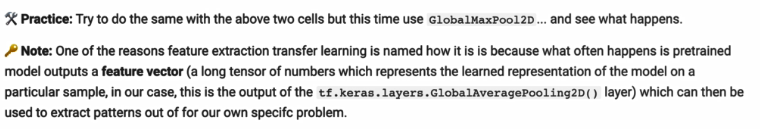

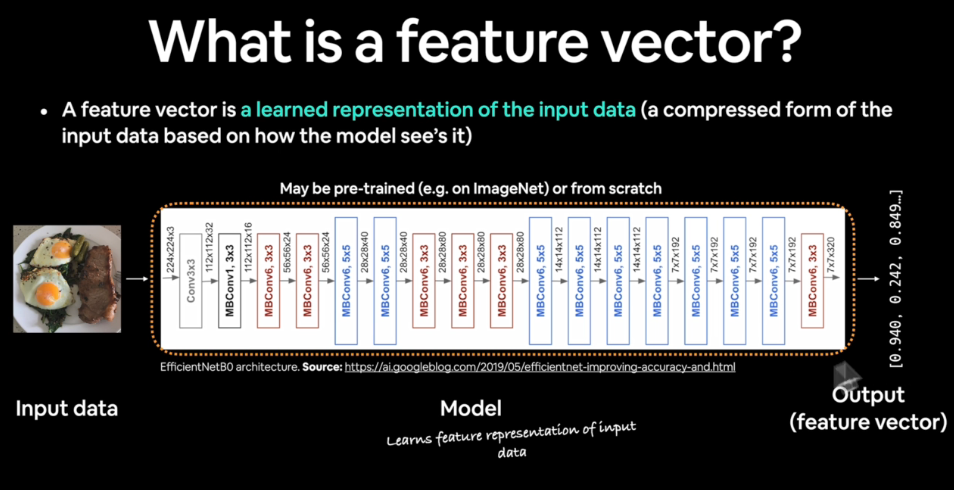

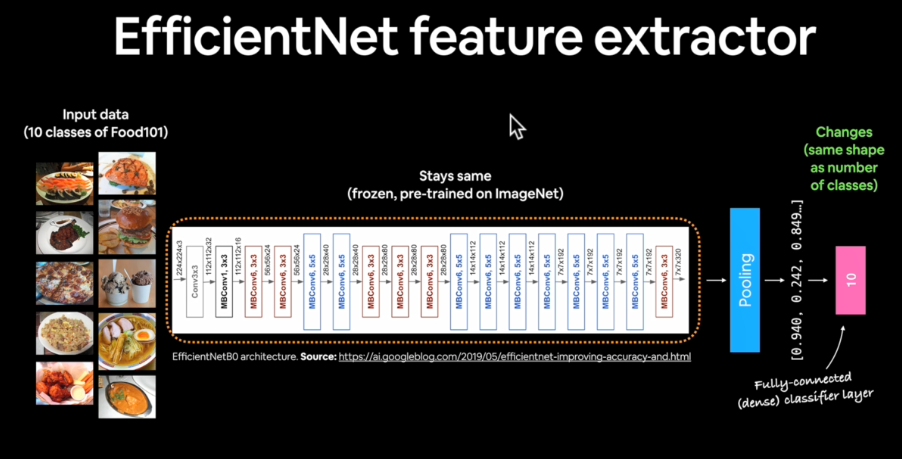

<h1 style="color:red">lec 010:-Downloading and preparing the data for Model 1 (1 percent of training data).mp4</h1>

## Running a series of transfer learning experiments

We've seen the incredible results transfer learning can get with only 10% of the training data, but how does it go with 1% of the training data... how about we set up a bunch of experiments to find out:

1. `model_1` - use feature extraction transfer learning with 1% of the training data  with data augmentation
2. `model_2` - use feature extraction transfer learning with 10% of the training with data augmentation

3. `model_3` - use fine-tuning transfer learning on 10% of the training data with data augmentation

4. `model_4` - use fine-tuning on 100% of the training data with data augmentation

> 🔑**Note:** throughout all experiments the same test dataset will be used to evaluate our model... this ensure consistency across evaluation metrics.


## Getting and preprocessing data for model_1

In [19]:
# Download and unzip data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
unzip_data("10_food_classes_1_percent.zip")

--2026-02-07 16:50:41--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.204.207, 172.217.203.207, 173.194.216.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.204.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133612354 (127M) [application/zip]
Saving to: ‘10_food_classes_1_percent.zip’

10_food_classes_1_p 100%[===================>] 127.42M   125MB/s    in 1.0s    

2026-02-07 16:50:42 (125 MB/s) - ‘10_food_classes_1_percent.zip’ saved [133612354/133612354]



In [20]:
# Create training and test dirs
train_dir_1_percent = "10_food_classes_1_percent/train"
test_dir = "10_food_classes_1_percent/test"

In [21]:
# How many images are we working with?
walk_through_dir("10_food_classes_1_percent")

There are 2 directories and 0 images in '10_food_classes_1_percent'.
There are 10 directories and 0 images in '10_food_classes_1_percent/train'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/sushi'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ice_cream'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/pizza'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ramen'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_wings'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/grilled_salmon'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/steak'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/hamburger'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/fried_rice'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_curry'.
There a

In [22]:
# Setup data loaders
IMG_SIZE = (224,224)
train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_1_percent,
                                                                           batch_size=32,
                                                                           label_mode="categorical",
                                                                           image_size=IMG_SIZE)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                batch_size=32,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


<h1 style="color:red">lec 011:-Building a data augmentation layer to use inside our model.mp4</h1>

## Adding data augmentation right into the model

To add data augmentation right into our models, we can use the layers inside:

* `tf.keras.layers.experimental.preprocessing()`

We can see the benefits of doing this within the TensorFlow Data augmentation documentation: https://www.tensorflow.org/guide/keras/preprocessing_layers#preprocessing_data_before_the_model_or_inside_the_model

Off the top our of heads, after reading the docs, the benefits of using data augmentation inside the model are:
* Preprocessing of image(augmenting them) happens on the GPU (much faster) rather than CPU.
* Image data augmentation only happens during training, so we can still export our whole model and use it elsewhere.

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Create data augmentation stage with horizontal flipping, rotation, zooms, etc
data_augmentation = keras.Sequential([
    layers.Input(shape=(224,224,3)), # to force shape and prevent lazy shape matching in sequential
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    # layers.Rescaling(1/255.) # keep for models like ResNet50v2 but EfficientNet's having rescaling built-in
], name="data_augmentation")

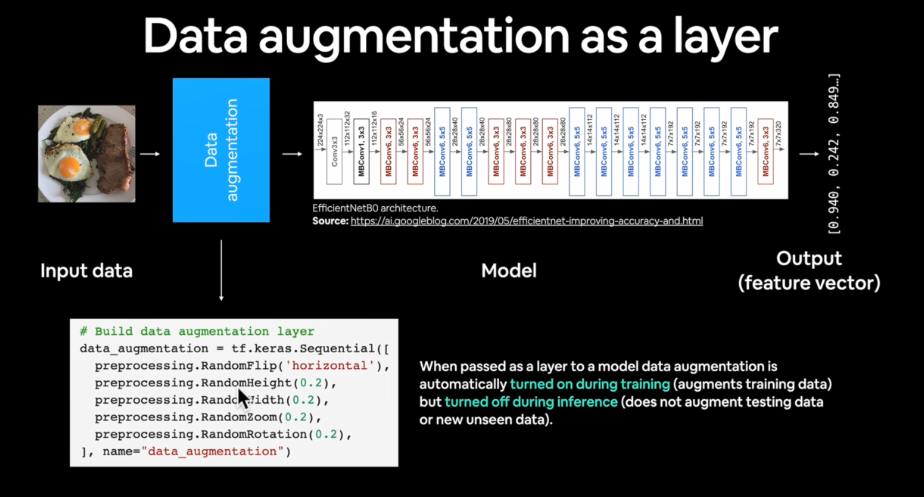

<h1 style="color:red">lec 012:-Visualising what happens when images pass through our data augmentation layer.mp4</h1>

### Visualize our data augmentation layer(and see what happens to our data)

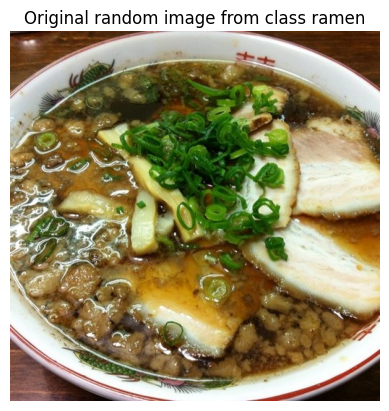

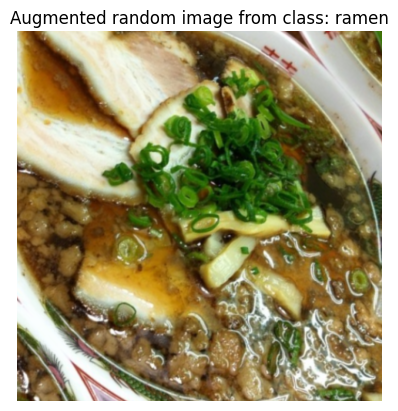

In [24]:
# View a random image and compare it to its augmented version
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

target_class = random.choice(train_data_1_percent.class_names)
target_dir = "10_food_classes_1_percent/train/"+target_class

random_image = random.choice(os.listdir(target_dir))
random_image_path = target_dir + "/" + random_image

# Read in the random image
img = mpimg.imread(random_image_path)
plt.imshow(img)
plt.title(f"Original random image from class {target_class}")
plt.axis(False);

# Now let's plot our augmented random image
augmented_img = data_augmentation(tf.expand_dims(img,axis=0))
plt.figure()
plt.imshow(tf.squeeze(augmented_img)/255.)
plt.title(f"Augmented random image from class: {target_class}")
plt.axis(False);

<h1 style="color:red">lec 013:-Building Model 1 (with a data augmentation layer and 1% of training data).mp4</h1>

## Model 1: Feature extraction transfer learning on 1% of the data with data augmentation


In [25]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# Setup input shape and base model, freezing the base model layers
input_shape = (224, 224, 3)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Create input layer
inputs = layers.Input(shape=input_shape,name="input_layer")

# Add in data augmentation Sequential model as a layer
x = data_augmentation(inputs)
x = layers.Lambda(preprocess_input)(x)

# Give the base model the inputs (after augmentation) and don't train it
x = base_model(x,training=False)

# Pool output features of the base model
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# Put a dense layer on as the output
outputs = layers.Dense(10,activation="softmax",name="output_layer")(x)

# Make a model with inputs and outputs
model_1 = tf.keras.Model(inputs,outputs)

# Compile the model
model_1.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_1_percent = model_1.fit(train_data_1_percent,
                                epochs=5,
                                steps_per_epoch=len(train_data_1_percent),
                                validation_data=test_data,
                                validation_steps=int(0.25*len(test_data)),
                                callbacks=[create_tensorboard_callback(dir_name="transfer_learning",
                                                                       experiment_name="1_percent_data_aug")])


Saving TensorBoard log files to: transfer_learning/1_percent_data_aug/20260207-165049
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 70s 26s/step - accuracy: 0.0676 - loss: 2.3770 - val_accuracy: 0.1530 - val_loss: 2.2568
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 25s/step - accuracy: 0.2315 - loss: 2.2096 - val_accuracy: 0.2385 - val_loss: 2.1306
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 54s 26s/step - accuracy: 0.3121 - loss: 2.0237 - val_accuracy: 0.2763 - val_loss: 2.0417
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 25s/step - accuracy: 0.4310 - loss: 1.8595 - val_accuracy: 0.3832 - val_loss: 1.9201
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 25s/step - accuracy: 0.5559 - loss: 1.6781 - val_accuracy: 0.4424 - val_loss: 1.8275


In [26]:
IMG_SIZE + (3,)

(224, 224, 3)

In [27]:
# Check out a model summary
model_1.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

In [28]:
# Evaluate on the full test dataset
results_1_percent_data_aug = model_1.evaluate(test_data)
results_1_percent_data_aug

79/79 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.4321 - loss: 1.8338


[1.8332849740982056, 0.42800000309944153]

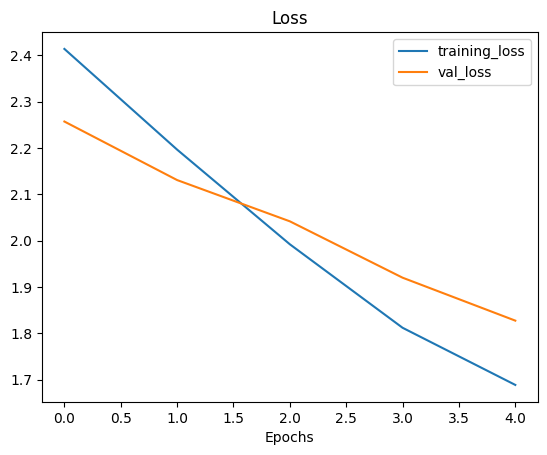

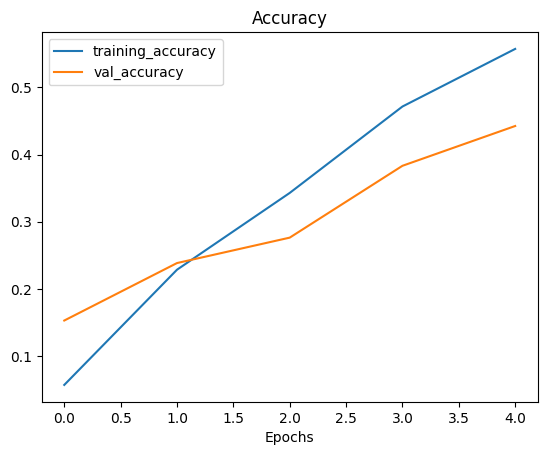

In [29]:
# Hoe do the model with 1% of the and data augmentation loss curves look?
plot_loss_curves(history_1_percent)

<h1 style="color:red">lec 014:-Building Model 2 (with a data augmentation layer and 10% of training data).mp4</h1>

## Model 2: feature extraction transfer learning model with 10% of data and data augmentation

In [30]:
# Get 10% of data... (uncomment it if you don't have it)
# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
# unzip_data("10_food_classes_10_percent.zip")

train_dir_10_percent = "10_food_classes_10_percent/train"
test_dir = "10_food_classes_10_percent/test"

In [31]:
# How many images are in our directory
walk_through_dir("10_food_classes_10_percent")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/c

In [32]:
# Set data inputs
import tensorflow as tf
IMG_SIZE = (224, 224)
train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_10_percent,
                                                                            label_mode="categorical",
                                                                            image_size=IMG_SIZE)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [33]:
data_augmentation.summary()

Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_height (RandomHeight)    │ (None, None, 224, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_width (RandomWidth)      │ (None, None, None, 3)  │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Create model 2 with data augmentation built in
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Setup the input shape to our model
input_shape=(224,224,3)

# Build data augmentation layer
data_augmentation = Sequential([
    layers.Input(shape=input_shape),
    layers.RandomFlip("horizontal"),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    # layers.Rescaling(1./255) # use it in resnet not here
])

# Create a frozen base model (also called the backbone)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Create the inputs and outputs (including the layers in between)
inputs = layers.Input(shape=input_shape,name="input_layer")
x = data_augmentation(inputs) # augment our training images (augmentation doesn't occur on test data)
x = base_model(x,training=False) # pass augmented images to base model but keep it in inference mode, this also ensures batchnorm layers don't get updated :- https://keras.io/guides/transfer_learning/
x = layers.GlobalAveragePooling2D(name="global_average_pooling2D")(x)
outputs = layers.Dense(10,activation="softmax",name="output_layer")(x)
model_2 = tf.keras.Model(inputs,outputs)

# Compile
model_2.compile(loss = "categorical_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics=["accuracy"])



In [35]:
model_2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2D        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

<h1 style="color:red">lec 015:-Creating a ModelCheckpoint to save our model's weights during training.mp4</h1>

### Creating a ModelCheckpoint callback

The ModelCheckpoint callback intermediately saves our model (the full model or just the weights) during training. This is useful so we can come and start where we left off.
https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint

**Keras ModelCheckpoint Format Rule (Keras 3+) — Summary**

In Keras 3 and later, `ModelCheckpoint` enforces strict file format extensions depending on what is being saved.

If `save_weights_only=True`, the filepath **must end with `.weights.h5`**.
If saving the full model, the recommended extension is **`.keras`** (or legacy `.h5`).

Older TensorFlow versions allowed `.ckpt` checkpoints, but Keras 3 separates TensorFlow checkpoint format from Keras serialization. Therefore, using `.ckpt` with `ModelCheckpoint` now raises a `ValueError`.

Correct usage examples:

Weights only:

```
filepath = "checkpoint.weights.h5"
save_weights_only = True
```

Full model:

```
filepath = "model.keras"
save_weights_only = False
```

Key rule:

* `.weights.h5` → weights only
* `.keras` → full model (architecture + weights + optimizer state)

This change breaks older TensorFlow tutorial code that used `.ckpt` with Keras callbacks.


In [36]:
# Set checkpoint path
checkpoint_path = "ten_percent_model_checkpoints_weights/checkpoint.weights.h5"

# Create a ModelCheckpoint callback that saves the model's weights only
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only=True,
                                                         save_best_only=False,
                                                         save_freq ="epoch",
                                                         monitor="val_loss",
                                                         verbose=1)

<h1 style="color:red">lec 016:-Fitting and evaluating Model 2 (and saving its weights using ModelCheckpoint).mp4</h1>

### Fit model 2 passing in the ModelCheckpoint callback

In [37]:
# Fit the model saving checkpoints every epoch
initial_epochs = 5
history_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                          epochs=initial_epochs,
                                          validation_data = test_data,
                                          validation_steps = int(0.25*len(test_data)),
                                          callbacks = [create_tensorboard_callback(dir_name="transfer_learning",
                                                                                   experiment_name="10_percent_data_aug"),
                                                       checkpoint_callback])

Saving TensorBoard log files to: transfer_learning/10_percent_data_aug/20260207-165942
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2240 - loss: 2.2172
Epoch 1: saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 128s 5s/step - accuracy: 0.2282 - loss: 2.2091 - val_accuracy: 0.6842 - val_loss: 1.4463
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6504 - loss: 1.4225
Epoch 2: saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 142s 5s/step - accuracy: 0.6513 - loss: 1.4192 - val_accuracy: 0.7895 - val_loss: 1.0050
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7540 - loss: 1.0796
Epoch 3: saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 107s 5s/step - accuracy: 0.7539 - loss: 1.0777 - val_accuracy: 0.8273 - val_loss: 0.8122
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.80

In [38]:
# What were model_0 results?
model_0.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.8592 - loss: 0.5672


[0.5571696162223816, 0.8623999953269958]

In [39]:
# Check model_2 results on all test_data
results_10_percent_data_aug = model_2.evaluate(test_data)
results_10_percent_data_aug

79/79 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.8341 - loss: 0.6431


[0.6296471953392029, 0.8407999873161316]

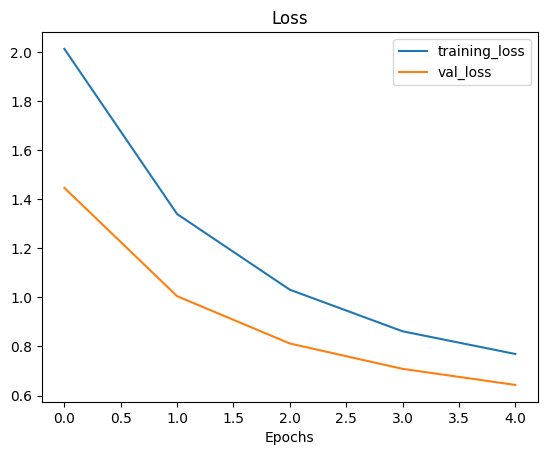

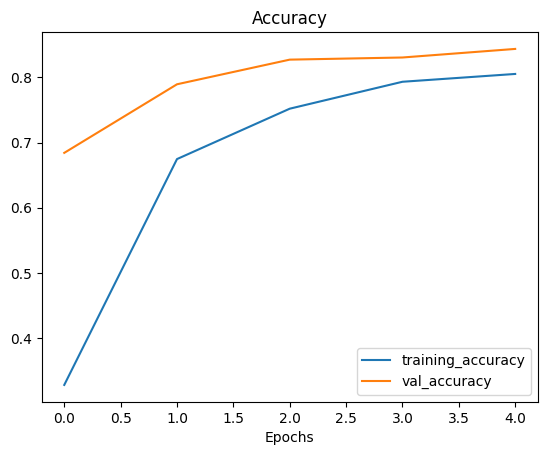

In [40]:
# Plot model loss curve
plot_loss_curves(history_10_percent_data_aug)

<h1 style="color:red">lec 017:-Loading and comparing saved weights to our existing trained Model 2.mp4</h1>

### Loading in checkpointed weights

Loading in checkpointed weights returns model to a specific checkpoint.

In [41]:
# Load in saved model weights and evaluate model
model_2.load_weights(checkpoint_path)

In [42]:
# Evaluate model_2 with the loaded weights
loaded_weights_model_results = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.8444 - loss: 0.6336


In [43]:
# If the results from our previously evaluated model_2 match the loaded weights, everything has worked!
results_10_percent_data_aug == loaded_weights_model_results

False

In [44]:
results_10_percent_data_aug

[0.6296471953392029, 0.8407999873161316]

In [45]:
loaded_weights_model_results

[0.6296472549438477, 0.8407999873161316]

In [46]:
# check to see if loaded model results are very close to our previous non-loaded model results
import numpy as np
np.isclose(results_10_percent_data_aug,loaded_weights_model_results)

array([ True,  True])

In [47]:
# Check the difference between the two results
print(np.array(results_10_percent_data_aug) - np.array(loaded_weights_model_results))

[-5.96046448e-08  0.00000000e+00]


<h1 style="color:red">lec 018:-Preparing Model 3 (our first fine-tuned model).mp4</h1>

## Model 3: Fine-tuning an existing model on 10% of the data

> 🔑**Note:** Fine-tuning usually works best after training a feature extraction model for a few epochs with large amonts of custom data.

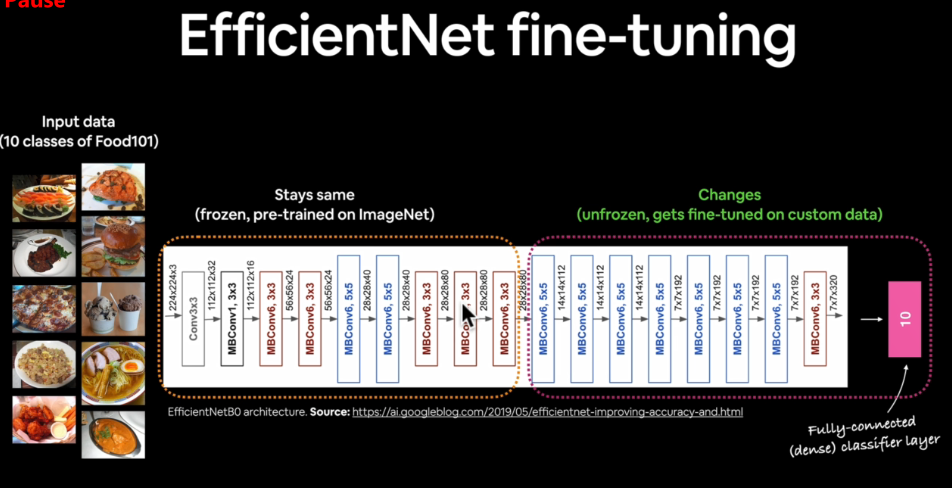

In [48]:
# Layers in loaded model
model_2.layers

[<InputLayer name=input_layer, built=True>,
 <Sequential name=sequential, built=True>,
 <Functional name=efficientnetb0, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2D, built=True>,
 <Dense name=output_layer, built=True>]

In [49]:
# Are these layers trainable?
for layer in model_2.layers:
  print(layer, layer.trainable)

<InputLayer name=input_layer, built=True> True
<Sequential name=sequential, built=True> True
<Functional name=efficientnetb0, built=True> False
<GlobalAveragePooling2D name=global_average_pooling2D, built=True> True
<Dense name=output_layer, built=True> True


In [50]:
# What layers are in our base_model (EfficientnetB0) and are they trainable?
for i, layer in enumerate(model_2.layers[2].layers):
  print(i, layer.name, layer.trainable)

0 input_layer_4 False
1 rescaling_4 False
2 normalization_2 False
3 rescaling_5 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [51]:
# How many trainable variables are in our base model?
print(len(model_2.layers[2].trainable_variables))

0


In [52]:
# To begin fine-tuning, let's start by setting the last 10 layers of our base_model.trainable=True
base_model.trainable=True

# Freeze all layers except for the last 10:
for layer in base_model.layers[:-10]:
  layer.trainable = False

# Recompile (we have to recompile our models every time we make a change)
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # When fine-tuning you typically want to lower the learning rate  by 10X.*
                metrics=["accuracy"])

> 🔑**Note:** When using fine-tuning it's best practice to lower your learning rate by some amount. How much? This is a hyperparameter you can tune. But a good rule of thumb is at least 10X (though different sources will claim other values).
A good resource for information on this is the `ULMFit paper`.
https://arxiv.org/abs/1801.06146

In [53]:
# Check which layers are tunable (trainable)
for layer_number, layer in enumerate(model_2.layers[2].layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_4 False
1 rescaling_4 False
2 normalization_2 False
3 rescaling_5 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [54]:
# Now we've unfrozen some of the layers closer to the top, How many trainable variables are there?
print(len(model_2.trainable_variables))

12


<h1 style="color:red">lec 019:-Fitting and evaluating Model 3 (our first fine-tuned model).mp4</h1>

In [55]:
# Fine tune for another 5 epochs
fine_tune_epochs = initial_epochs + 5

# Refit the model (same as model_2 except with more trainable layers)
history_fine_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                               epochs = fine_tune_epochs,
                                               validation_data=test_data,
                                               validation_steps=int(0.25*len(test_data)),
                                               initial_epoch = history_10_percent_data_aug.epoch[-1], # start training from previous last epoch
                                               callbacks = [create_tensorboard_callback(dir_name="transfer_learning",
                                                                                        experiment_name="10_percent_fine_tune_last_10")]
                                               )

Saving TensorBoard log files to: transfer_learning/10_percent_fine_tune_last_10/20260207-172050
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 130s 5s/step - accuracy: 0.7956 - loss: 0.8121 - val_accuracy: 0.8438 - val_loss: 0.5772
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.8541 - loss: 0.6267 - val_accuracy: 0.8553 - val_loss: 0.5227
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 111s 5s/step - accuracy: 0.8491 - loss: 0.5865 - val_accuracy: 0.8536 - val_loss: 0.4940
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 108s 5s/step - accuracy: 0.8578 - loss: 0.5266 - val_accuracy: 0.8520 - val_loss: 0.4784
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 111s 5s/step - accuracy: 0.8844 - loss: 0.4741 - val_accuracy: 0.8569 - val_loss: 0.4682
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.9062 - loss: 0.4108 - val_accuracy: 0.8701 - val_loss: 0.4446


In [56]:
# Evaluate the fine-tuned model (model_3 which is actually model_2 fine-tuned for another 5 epochs)
results_fine_tune_10_percent = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.8703 - loss: 0.4292


In [57]:
results_10_percent_data_aug

[0.6296471953392029, 0.8407999873161316]

<h1 style="color:red">lec 020:-Comparing our model's results before and after fine-tuning.mp4</h1>


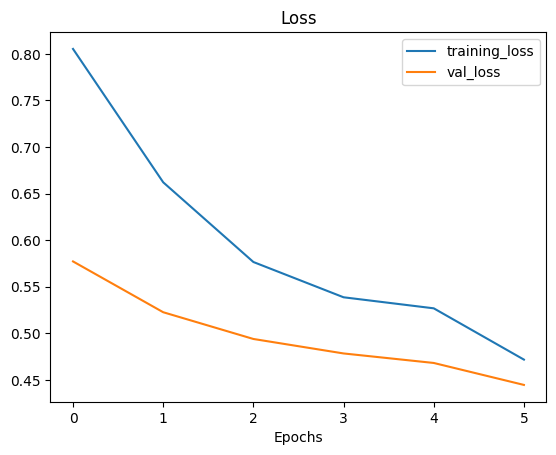

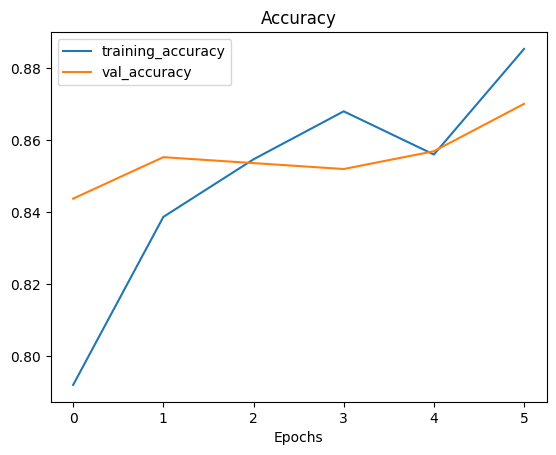

In [58]:
# Check out the loss curves of our fine-tuned model
plot_loss_curves(history_fine_10_percent_data_aug)

The `plot_loss_curves` function works great with models which have only been fit once, however, we want something to compare one series of running `fit()` with another (e.g. before and after fine tuning).

In [59]:
import matplotlib.pyplot as plt

# Let's create a function to compare training histories
def compare_history(original_history,new_history,initial_epochs=5):
  """
  Compare two model.fit history objects.
  """
  # Get original history measurements
  acc = original_history.history["accuracy"]
  loss = original_history.history["loss"]

  val_acc = original_history.history["val_accuracy"]
  val_loss = original_history.history["val_loss"]

  # Combine original history metrics with new_history metrics
  total_acc = acc + new_history.history["accuracy"]
  total_loss = loss + new_history.history["loss"]

  total_val_acc = val_acc + new_history.history["val_accuracy"]
  total_val_loss = val_loss + new_history.history["val_loss"]

  # Make plot for accuracy
  plt.figure(figsize=(8,8))
  plt.subplot(2,1,1)
  plt.plot(total_acc,label="Training Accuracy")
  plt.plot(total_val_acc,label="Validation Accuracy")
  plt.plot([initial_epochs-1,initial_epochs-1],plt.ylim(),label="Start Fine tuning")
  plt.legend(loc="lower right")
  plt.title("Training and Validation Accuracy")

  # Make plot for loss
  plt.figure(figsize=(8,8))
  plt.subplot(2,1,2)
  plt.plot(total_loss,label="Training Loss")
  plt.plot(total_val_loss,label="Validation Loss")
  plt.plot([initial_epochs-1,initial_epochs-1],plt.ylim(),label="Start Fine tuning")
  plt.legend(loc="upper right")
  plt.title("Training and Validation Loss")

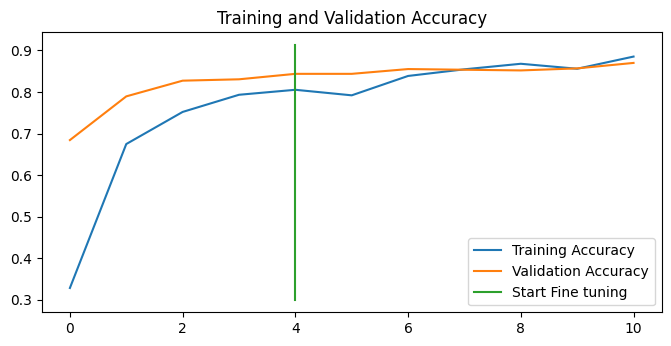

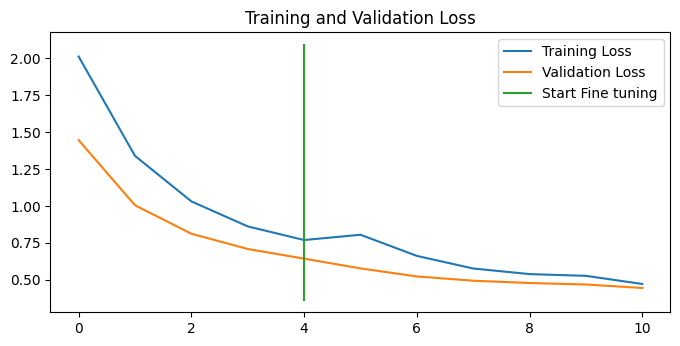

In [60]:
compare_history(history_10_percent_data_aug,
                history_fine_10_percent_data_aug,
                initial_epochs=5)

<h1 style="color:red">lec 021:-Downloading and preparing data for our biggest experiment yet (Model 4).mp4</h1>

## Model 4: Fine-tuning and existing model on all the data

In [61]:
# Download and unzip 10 classes of Food101 data with all images
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
unzip_data("10_food_classes_all_data.zip")

--2026-02-07 17:35:50--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.139.207, 173.194.210.207, 173.194.212.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.139.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  72.8MB/s    in 7.5s    

2026-02-07 17:35:57 (65.8 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [62]:
# Setup training and test dir
training_dir_all_data = "10_food_classes_all_data/train"
test_dir = "10_food_classes_all_data/test"

In [63]:
# How many images are we working with now?
walk_through_dir("10_food_classes_all_data")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/train'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/sushi'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ice_cream'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/pizza'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ramen'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_wings'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/grilled_salmon'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/steak'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/hamburger'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/fried_rice'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_curry'.

In [64]:
# Setup data inputs
import tensorflow as tf
IMG_SIZE = (224,224)
train_data_10_classes_full = tf.keras.preprocessing.image_dataset_from_directory(training_dir_all_data,
                                                                                 image_size=IMG_SIZE,
                                                                                 label_mode="categorical")

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                image_size=IMG_SIZE,
                                                                label_mode="categorical")

Found 7500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


<h1 style="color:red">lec 022:-Preparing our final modelling experiment (Model 4).mp4</h1>

The test dataset we've loaded in is the same as what we've been using for previous experiments (all experiments have used the same test dataset).

Let's verify thus...

In [65]:
# Evaluate model 2 (this is the fine-tuned on 10 percent of data version)
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.8665 - loss: 0.4124


[0.4322885274887085, 0.8668000102043152]

In [66]:
results_fine_tune_10_percent

[0.4322884678840637, 0.8668000102043152]

To train a fine-tuning model (model_4) we need to revert model_2 back to its feature extraction weights.

In [67]:
# Load weights from checkpoint, that way we can fine-tune from
# the same stage the 10 percent data model was fine-tuned from
model_2.load_weights(checkpoint_path)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [68]:
# Let's evaluate model_2 now
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.8468 - loss: 0.6030


[0.6296470761299133, 0.8407999873161316]

In [69]:
# check to see if our model_2 has been reverted back to feature extraction results
results_10_percent_data_aug

[0.6296471953392029, 0.8407999873161316]

Alright, the previous steps might seem quite confusing but all we've done is:

1. Trained a feature extraction transfer learning model for 5 epochs on 10% of the data with data augmentation (model_2) and we saved the model's weights using `ModelCheckpoint` callback.

2. Fine-tuned the same model on the same 10% of the data for a further 5 epochs with the top 10 layers of the base model unfrozen (model_3).

3. Saved the results and training logs each time.

4. Reloaded the model from step 1 to do the same steps as step 2 expect this time we're going to use all of the data (model_4).

In [70]:
# Check which layers are tunable in the whole model
for layer_number, layer in enumerate(model_2.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer True
1 sequential True
2 efficientnetb0 True
3 global_average_pooling2D True
4 output_layer True


Note:- even only few layers are trainable in efficientnetB0 it will be marked as trainable

In [71]:
# Let's drill into our base_model (efficientnetB0) and see what layers are trainable
for layer_number, layer in enumerate(model_2.layers[2].layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_4 False
1 rescaling_4 False
2 normalization_2 False
3 rescaling_5 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

<h1 style="color:red">lec 023:-Fine-tuning Model 4 on 100% of the training data and evaluating its results.mp4</h1>

In [72]:
# Compile
model_2.compile(
    loss="categorical_crossentropy",
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001), # 0.1x lr for fine-tuning
    metrics=["accuracy"]
)

In [76]:
# Continue to train and fine-tune the model to our data (100% of the training data)
fine_tune_epochs = initial_epochs+5

history_fine_10_classes_full = model_2.fit(train_data_10_classes_full,
                                           epochs = fine_tune_epochs,
                                           validation_data = test_data,
                                           validation_steps = int(0.25*len(test_data)),
                                           initial_epoch = history_10_percent_data_aug.epoch[-1],
                                           callbacks=[create_tensorboard_callback(dir_name="transfer_learning",
                                                                                  experiment_name="full_10_classes_fine_tune_last_10")])

Saving TensorBoard log files to: transfer_learning/full_10_classes_fine_tune_last_10/20260207-174619
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 716s 3s/step - accuracy: 0.7570 - loss: 0.8436 - val_accuracy: 0.8914 - val_loss: 0.3255
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 735s 3s/step - accuracy: 0.8178 - loss: 0.5923 - val_accuracy: 0.9095 - val_loss: 0.2771
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 723s 3s/step - accuracy: 0.8360 - loss: 0.5295 - val_accuracy: 0.9112 - val_loss: 0.2504
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 749s 3s/step - accuracy: 0.8424 - loss: 0.4666 - val_accuracy: 0.9145 - val_loss: 0.2324
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 706s 3s/step - accuracy: 0.8578 - loss: 0.4438 - val_accuracy: 0.9161 - val_loss: 0.2505
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 753s 3s/step - accuracy: 0.8664 - loss: 0.4166 - val_accuracy: 0.9211 - val_loss: 0.2266


In [77]:
# Let's evaluate on all of the test data
results_fine_tune_full_data = model_2.evaluate(test_data)
results_fine_tune_full_data

79/79 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.9174 - loss: 0.2437


[0.26518958806991577, 0.9136000275611877]

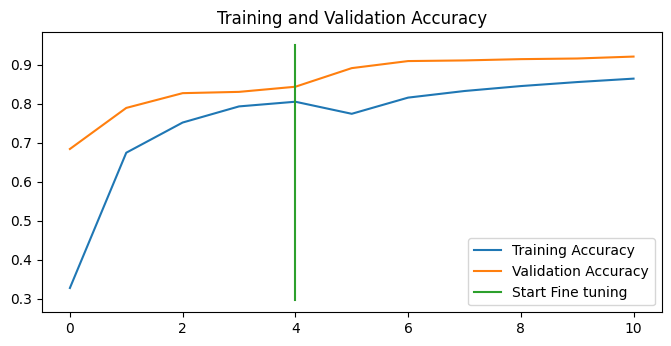

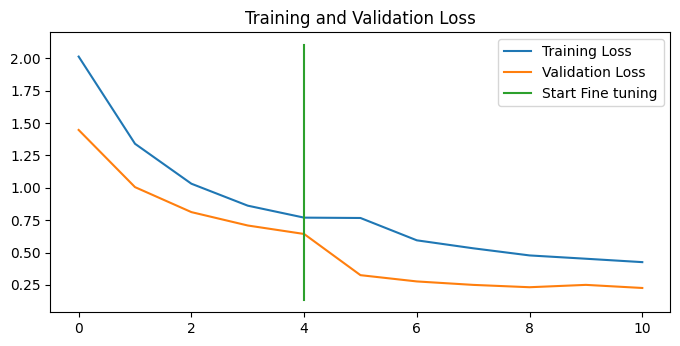

In [78]:
# How did fine-tuning go with more data?
compare_history(original_history=history_10_percent_data_aug,
                new_history = history_fine_10_classes_full,
                initial_epochs=5)

In [79]:
%tensorboard --logdir transfer_learning

UsageError: Line magic function `%tensorboard` not found.


<body>
                <div class="container">
                <div class="row">
                <div class="col-md-10 col-md-offset-1">
                    <p class="lead"><p>Oh. My. Goodness.</p><p>We just trained our best model yet using the power of transfer learning and fine-tuning!</p><p>And you had practice setting up and running a set of machine learning modelling experiments and comparing them using TensorBoard.</p><p>Serial-experimenting is an important skill for any machine learning practitioner.</p><p>Remember the machine learning practitioner’s motto?</p><p>“Experiment, experiment, experiment!”</p><p>You’re living up to it!</p><p>You should now be able to:</p><ul><li><p>Think about and design machine learning experiments (start small and increase when necessary)</p></li><li><p>Build transfer learning feature extraction models with tf.keras.applications</p></li><li><p>Create data augmentation layers and build them right into your models</p></li><li><p>Compare your modelling experiments on TensorBoard and visualise them on TensorBoard.dev</p></li></ul><p>Far out, you’ve covered a lot of ground in this module.</p><p>But don’t stop there, put your new skills into practice.</p><p>In the <a href="https://github.com/mrdbourke/tensorflow-deep-learning" rel="noopener noreferrer" target="_blank">course GitHub repo</a> under “Course materials”, you'll find a series of exercises and extra-curriculum suggestions.</p><p>You should go through these <strong>before</strong> moving on to the next section.</p><p>See the link below for more.</p><ul><li><p><a href="https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/README.md#-05-transfer-learning-in-tensorflow-part-2-fine-tuning-exercises" rel="noopener noreferrer" target="_blank">Transfer Learning in TensorFlow Part 2: Fine-tuning Exercises &amp; Extra-curriculum</a></p></li></ul><p>And remember, if you have any questions, be sure to <a href="https://github.com/mrdbourke/tensorflow-deep-learning/discussions" rel="noopener noreferrer" target="_blank">add them to the discussions page</a>.</p><p><strong>Challenge:</strong> Recreate one of the experiments we did with the <a href="https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetB4" rel="noopener noreferrer" target="_blank">EfficientNetB4 architecture in the tf.keras.applications module</a>. How does it go? Did it improve our results?</p><p>Send a message with your results to the #machinelearning-datascience channel on Discord and mention my name (@mrdbourke), I’d love to see what happens!</p><p>See you in the next module!</p><p>- Daniel</p><p>Web: <a href="http://www.mrdbourke.com/" rel="noopener noreferrer" target="_blank">www.mrdbourke.com</a></p><p>YouTube: <a href="https://dbourke.link/youtube" rel="noopener noreferrer" target="_blank">https://dbourke.link/youtube</a></p></p>
                </div>
                </div>
                </div>
                <script src="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/js/bootstrap.min.js" integrity="sha384-Tc5IQib027qvyjSMfHjOMaLkfuWVxZxUPnCJA7l2mCWNIpG9mGCD8wGNIcPD7Txa" crossorigin="anonymous"></script>
                </body>